In [1]:
import random
import os
import ast
import time
import requests
import pandas as pd
import numpy as np
import joblib
import seaborn as sns
import matplotlib.pyplot as plt

from collections import Counter
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import MultiLabelBinarizer, MinMaxScaler
from dotenv import load_dotenv
load_dotenv()

True

In [2]:
# в этой папке храним датасеты
os.makedirs('data', exist_ok=True)

In [ ]:
# Из-за ограничений апи, используется несколько токенов
TOKENS = [os.getenv(f"KP_TOKEN_{i}") for i in range(1, 8)]
TOKENS = [t for t in TOKENS if t]

piriods = [
    (1990, 1998),
    (1999, 2004),
    (2005, 2009),
    (2010, 2013),
    (2014, 2017),
    (2018, 2021),
    (2022, 2024),
]

limit = 250
pgs_amount = 10

req_fields = [
    "id", "name", "alternativeName", "year", "description",
    "genres", "countries", "rating", "votes", "movieLength",
    "ageRating", "poster",
]


def get_movie_info(raw: dict) -> dict:
    """Метод получения искомых полей из респонса апи"""
    genres_info = raw.get("genres")
    genres = [g["name"] for g in genres_info if isinstance(g, dict)] \
        if isinstance(genres_info, list) else []

    countries_info = raw.get("countries")
    countries = [c["name"] for c in countries_info if isinstance(c, dict)] \
        if isinstance(countries_info, list) else []

    rating = raw.get("rating") or {}
    votes = raw.get("votes") or {}
    poster = raw.get("poster") or {}

    return {
        "id": raw.get("id"),
        "name": raw.get("name"),
        "alternative_name": raw.get("alternativeName"),
        "year": raw.get("year"),
        "description": raw.get("description"),
        "genres": genres,
        "countries": countries,
        "rating_kp": rating.get("kp") if isinstance(rating, dict) else None,
        "rating_imdb": rating.get("imdb") if isinstance(rating, dict) else None,
        "votes_kp": votes.get("kp") if isinstance(votes, dict) else None,
        "votes_imdb": votes.get("imdb") if isinstance(votes, dict) else None,
        "movie_length": raw.get("movieLength"),
        "age_rating": raw.get("ageRating"),
        "poster_url": poster.get("url") if isinstance(poster, dict) else None,
    }


def req_info(token, year_from, year_to) -> list:
    """Запрос на получения инфомрации о фильме через апи"""
    headers = {"X-API-KEY": token}
    res = []
    for page in range(1, pgs_amount + 1):
        params = [
            ("page", page),
            ("limit", limit),
            ("sortField", "votes.kp"),
            ("sortType", "-1"),
            ("type", "movie"),
            ("votes.kp", "1000-99999999"),
            ("year", f"{year_from}-{year_to}"),
        ]
        for f in req_fields:
            params.append(("selectFields", f))

        resp = requests.get(
            "https://api.poiskkino.dev/v1.4/movie",
            headers=headers, 
            params=params
        )

        if resp.status_code == 200:
            docs = resp.json().get("docs", [])
            if not docs:
                break
            res.extend(get_movie_info(d) for d in docs)
            print(f"  [{year_from}-{year_to}] стр.{page}: +{len(docs)} "
                  f"(сегмент: {len(res)})")

        else:
            print(f"  [{year_from}-{year_to}] стр.{page}: ошибка {resp.status_code}")
            break

        time.sleep(0.2)

    return res


all_movies = []
n = min(len(TOKENS), len(piriods))

for i in range(n):
    token = TOKENS[i]
    yf, yt = piriods[i]
    print(f"Токен {i + 1}  за период {yf}-{yt}")
    all_movies.extend(req_info(token, yf, yt))
    print()

df = pd.DataFrame(all_movies)
before = len(df)
df = df[df["name"].notna() & df["year"].notna()]
df = df.drop_duplicates(subset="id").reset_index(drop=True)

os.makedirs("data", exist_ok=True)
df.to_csv("data/movies.csv", index=False)
print("Сохранено: data/movies.csv")

Доступно токенов: 7, сегментов: 7, используем: 7

Токен 1 → годы 1990-1998
  [1990-1998] стр.1: +250 (сегмент: 250)
  [1990-1998] стр.2: +250 (сегмент: 500)
  [1990-1998] стр.3: +250 (сегмент: 750)
  [1990-1998] стр.4: +250 (сегмент: 1000)
  [1990-1998] стр.5: +250 (сегмент: 1250)
  [1990-1998] стр.6: +250 (сегмент: 1500)
  [1990-1998] стр.7: +250 (сегмент: 1750)
  [1990-1998] стр.8: +250 (сегмент: 2000)
  [1990-1998] стр.9: +250 (сегмент: 2250)
  [1990-1998] стр.10: +126 (сегмент: 2376)

Токен 2 → годы 1999-2004
  [1999-2004] стр.1: +250 (сегмент: 250)
  [1999-2004] стр.2: +250 (сегмент: 500)
  [1999-2004] стр.3: +250 (сегмент: 750)
  [1999-2004] стр.4: +250 (сегмент: 1000)
  [1999-2004] стр.5: +250 (сегмент: 1250)
  [1999-2004] стр.6: +250 (сегмент: 1500)
  [1999-2004] стр.7: +250 (сегмент: 1750)
  [1999-2004] стр.8: +250 (сегмент: 2000)
  [1999-2004] стр.9: +248 (сегмент: 2248)

Токен 3 → годы 2005-2009
  [2005-2009] стр.1: +250 (сегмент: 250)
  [2005-2009] стр.2: +250 (сегмент: 500

In [3]:
df = pd.read_csv("data/movies.csv")
df.head()

,id,name,alternative_name,year,description,genres,countries,rating_kp,rating_imdb,votes_kp,votes_imdb,movie_length,age_rating,poster_url
0,41519,Брат,Брат,1997,"Демобилизовавшись, Данила Багров возвращается ...","['драма', 'криминал', 'боевик']",['Россия'],8.373,7.8,1759180,28000.0,96.0,18.0,https://avatars.mds.yandex.net/get-kinopoisk-i...
1,8124,Один дома,Home Alone,1990,Американское семейство отправляется из Чикаго ...,"['комедия', 'семейный']",['США'],8.282,7.8,1280559,740000.0,103.0,0.0,https://avatars.mds.yandex.net/get-kinopoisk-i...
2,326,Побег из Шоушенка,The Shawshank Redemption,1994,Бухгалтер Энди Дюфрейн обвинён в убийстве собс...,['драма'],['США'],9.111,9.3,1126812,3200000.0,142.0,18.0,https://avatars.mds.yandex.net/get-kinopoisk-i...
3,448,Форрест Гамп,Forrest Gump,1994,"Сидя на автобусной остановке, Форрест Гамп — н...","['драма', 'комедия', 'мелодрама', 'история', '...",['США'],8.921,8.8,993343,2500000.0,142.0,18.0,https://avatars.mds.yandex.net/get-kinopoisk-i...
4,2213,Титаник,Titanic,1997,Апрель 1912 года. В первом и последнем плавани...,"['мелодрама', 'триллер', 'драма']",['США'],8.389,8.0,943610,1400000.0,194.0,12.0,https://avatars.mds.yandex.net/get-kinopoisk-i...


In [4]:
print(f"Всего фильмов: {len(df)}\n")
missing = pd.DataFrame({
    'пропусков': df.isna().sum(),
    'процент': (df.isna().sum() / len(df) * 100).round(1)
})
display(missing)

Всего фильмов: 17096



,пропусков,процент
id,0,0.0
name,1,0.0
alternative_name,0,0.0
year,0,0.0
description,115,0.7
genres,0,0.0
countries,0,0.0
rating_kp,33,0.2
rating_imdb,1039,6.1
votes_kp,0,0.0


**Обработка пропусков**

In [5]:
display(df[df['name'].isna()])
# нашел название в интеренете 
df.loc[df['name'].isna(), 'name'] = 'Не отпускай его'
display(df.loc[df["name"] == "Не отпускай его"][["name"]])

,id,name,alternative_name,year,description,genres,countries,rating_kp,rating_imdb,votes_kp,votes_imdb,movie_length,age_rating,poster_url
11955,842226,NaN,Holding the Man,2015,NaN,"['драма', 'мелодрама', 'биография', 'история']",['Австралия'],6.634,7.5,2606,14000.0,127.0,18.0,https://avatars.mds.yandex.net/get-kinopoisk-i...


,name
11955,Не отпускай его


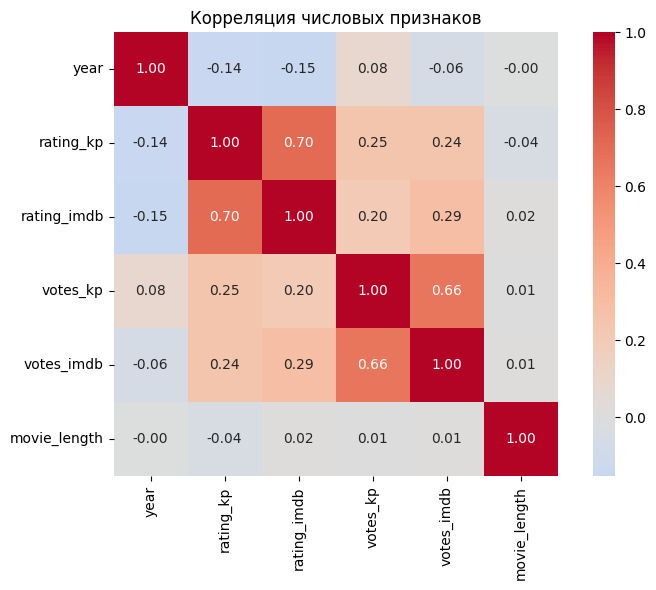

,year,rating_kp,rating_imdb,votes_kp,votes_imdb,movie_length
year,1.000000,-0.143890,-0.153039,0.082779,-0.055411,-0.003379
rating_kp,-0.143890,1.000000,0.703573,0.251394,0.243806,-0.036126
rating_imdb,-0.153039,0.703573,1.000000,0.203905,0.290872,0.016119
votes_kp,0.082779,0.251394,0.203905,1.000000,0.660300,0.008917
votes_imdb,-0.055411,0.243806,0.290872,0.660300,1.000000,0.011600
movie_length,-0.003379,-0.036126,0.016119,0.008917,0.011600,1.000000


In [6]:
num_cols = ['year', 'rating_kp', 'rating_imdb', 'votes_kp', 'votes_imdb', 'movie_length']
corr = df[num_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.title('Корреляция числовых признаков')
plt.tight_layout()
plt.show()

display(corr)

Высокая корреляция между рейтингом на кинопоиске и на IMDB делает признаки почти идентичными, нет смысла использовать оба признака для обучения модели

In [7]:
# Заполняем пропуски оценок с кинопоиска идентичной информации с другого сайта
df['rating_kp'] = df['rating_kp'].fillna(df['rating_imdb'])

print("Пропуски после заполнения:")
print(f"  rating_kp:   {df['rating_kp'].isna().sum()}")
print(f"  rating_imdb: {df['rating_imdb'].isna().sum()}")

Пропуски после заполнения:
  rating_kp:   10
  rating_imdb: 1039


In [8]:
# Остальные пропуски заполеняем медианным значением
median_kp = df['rating_kp'].median()
df['rating_kp'] = df['rating_kp'].fillna(median_kp)

print(f"Медиана rating_kp: {median_kp:.2f}")
print(f"Пропуски rating_kp после заполнения: {df['rating_kp'].isna().sum()}")

Медиана rating_kp: 6.64
Пропуски rating_kp после заполнения: 0


In [9]:
# Также заполняем пропуски продолжительности фильма медианой
median_length = df['movie_length'].median()
df['movie_length'] = df['movie_length'].fillna(median_length)

print(f"Медиана длины: {median_length:.0f} мин")
print(f"Пропуски movie_length после заполнения: {df['movie_length'].isna().sum()}")

Медиана длины: 100 мин
Пропуски movie_length после заполнения: 0


In [10]:
# Обработка дублей 
df = df.drop_duplicates(subset=['id'])
print("Фильмов осталось: ", len(df))

Фильмов осталось:  17096


In [11]:
# Изменение типа данных колонки genres
df['genres_list'] = df['genres'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else [])
type(df.genres_list[0])

list

In [12]:
genre_counts = Counter(g for genres in df['genres_list'] for g in genres)
print(f"Всего уникальных жанров: {len(genre_counts)}\n")
for g, cnt in genre_counts.most_common():
    print(f"  {g:20} {cnt:>5} ({cnt/len(df)*100:.1f}%)")

Всего уникальных жанров: 30

  драма                 8452 (49.4%)
  комедия               5625 (32.9%)
  триллер               4347 (25.4%)
  мелодрама             3589 (21.0%)
  боевик                3256 (19.0%)
  криминал              2871 (16.8%)
  ужасы                 2298 (13.4%)
  приключения           1838 (10.8%)
  детектив              1718 (10.0%)
  фантастика            1626 (9.5%)
  фэнтези               1450 (8.5%)
  семейный              1113 (6.5%)
  биография             1024 (6.0%)
  история                870 (5.1%)
  военный                673 (3.9%)
  документальный         542 (3.2%)
  музыка                 452 (2.6%)
  спорт                  440 (2.6%)
  короткометражка        341 (2.0%)
  мюзикл                 194 (1.1%)
  вестерн                154 (0.9%)
  для взрослых            35 (0.2%)
  концерт                 20 (0.1%)
  детский                 20 (0.1%)
  реальное ТВ             11 (0.1%)
  церемония                6 (0.0%)
  новости                 

In [13]:
# Удаляем неподходящие для работы жанры фильмов
trash_genres = {'для взрослых', 'концерт', 'реальное ТВ', 'церемония', 'новости', 'ток-шоу', 'игра'}

before = len(df)
df = df[~df['genres_list'].apply(lambda gs: any(g in trash_genres for g in gs))].reset_index(drop=True)
print(f"Удалено: {before - len(df)}, осталось: {len(df)}")

Удалено: 79, осталось: 17017


In [14]:
# оставляем необходимые поля 
columns_to_keep = [
    'id',
    'name',
    'year',
    'genres_list',
    'countries',
    'rating_kp',
    'rating_imdb',
    'votes_kp',
    'movie_length',
    'poster_url',
    'description'
]

df_copy = df[columns_to_keep].copy()
display(df_copy.head())

,id,name,year,genres_list,countries,rating_kp,rating_imdb,votes_kp,movie_length,poster_url,description
0,41519,Брат,1997,"[драма, криминал, боевик]",['Россия'],8.373,7.8,1759180,96.0,https://avatars.mds.yandex.net/get-kinopoisk-i...,"Демобилизовавшись, Данила Багров возвращается ..."
1,8124,Один дома,1990,"[комедия, семейный]",['США'],8.282,7.8,1280559,103.0,https://avatars.mds.yandex.net/get-kinopoisk-i...,Американское семейство отправляется из Чикаго ...
2,326,Побег из Шоушенка,1994,[драма],['США'],9.111,9.3,1126812,142.0,https://avatars.mds.yandex.net/get-kinopoisk-i...,Бухгалтер Энди Дюфрейн обвинён в убийстве собс...
3,448,Форрест Гамп,1994,"[драма, комедия, мелодрама, история, военный]",['США'],8.921,8.8,993343,142.0,https://avatars.mds.yandex.net/get-kinopoisk-i...,"Сидя на автобусной остановке, Форрест Гамп — н..."
4,2213,Титаник,1997,"[мелодрама, триллер, драма]",['США'],8.389,8.0,943610,194.0,https://avatars.mds.yandex.net/get-kinopoisk-i...,Апрель 1912 года. В первом и последнем плавани...


In [15]:
# Меняем тип данных для колонки countries
df_copy['countries'] = df_copy['countries'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else [])
type(df_copy.countries[0])

list

In [16]:
# Удаляем нелогичные/нереальные значения
df_copy[(df_copy['movie_length'] < 5) | (df_copy['movie_length'] > 600)][['name', 'year', 'movie_length', 'genres_list']]

,name,year,movie_length,genres_list
686,Жук-скакун,1997,3.0,"[короткометражка, фэнтези, детектив]"
2017,Назад в будущее... Поездка,1991,4.0,"[короткометражка, фантастика, приключения]"
2035,Правда или желание,1995,4.0,"[короткометражка, драма, комедия]"
3429,Люди в черном: Атака чужого,2000,4.0,"[короткометражка, фантастика, боевик]"
4186,Пекановый пирог,2004,2.0,"[короткометражка, мюзикл, комедия]"
6388,Соседи по кровати,2008,3.0,"[короткометражка, ужасы, драма]"
6419,Черная дыра,2008,3.0,"[короткометражка, драма, комедия, криминал, де..."
8236,Моя возлюбленная,2012,3.0,"[короткометражка, музыка]"
8272,Короткометражка Marvel: Забавный случай на пут...,2011,4.0,"[короткометражка, боевик, комедия, приключения]"
8294,Короткометражка Marvel: Консультант,2011,4.0,"[короткометражка, фантастика, драма, комедия]"


In [17]:
# Обрабатываем "особый" эксперменетальный фильм с аномальной продолжительностью, но она реальна
median_len = df_copy.loc[df_copy['movie_length'] <= 600, 'movie_length'].median()
exceptional_movie = df_copy['movie_length'] > 600
df_copy.loc[exceptional_movie, 'movie_length'] = median_len
print("done")

done


In [18]:
# Заполняем пропуски для веб-интерфейса
median_kp = df_copy.loc[df_copy['rating_kp'] >= 1, 'rating_kp'].median()
df_copy.loc[df_copy['rating_kp'] < 1, 'rating_kp'] = median_kp
df_copy.loc[df_copy['rating_imdb'] == 0, 'rating_imdb'] = np.nan

In [19]:
# Кодируем жанры
multi_label_binarizer = MultiLabelBinarizer()
genres_numeric = multi_label_binarizer.fit_transform(df_copy["genres_list"])
print(f"Жанры: {genres_numeric.shape[1]} признаков")

# Нормализация числовых признаков
year_scaler = MinMaxScaler()
rating_scaler = MinMaxScaler()
length_scaler = MinMaxScaler()
votes_scaler = MinMaxScaler()

year_normal = year_scaler.fit_transform(df_copy[["year"]])
rating_normal = rating_scaler.fit_transform(df_copy[["rating_kp"]])
length_normal = length_scaler.fit_transform(df_copy[["movie_length"]])

votes_log = np.log1p(df_copy[["votes_kp"]])
votes_normal = votes_scaler.fit_transform(votes_log)

feature_matrix_final = np.hstack([
    genres_numeric, year_normal, rating_normal, length_normal, votes_normal
])

print(f"Финальная матрица: {feature_matrix_final.shape}")

Жанры: 23 признаков


Финальная матрица: (17017, 27)


**Построение контентной модели**

In [20]:
knn = NearestNeighbors(n_neighbors=11, metric='cosine')
knn.fit(feature_matrix_final)
print("Модель готова!")

Модель готова!


In [21]:
idx = random.randint(0, len(df_copy) - 1)
movie = df_copy.iloc[idx]

# Поиск похожих
distances, indices = knn.kneighbors(feature_matrix_final[idx:idx+1])

print("Фильм:", movie['name'])
print("Жанры:", movie['genres_list'])
print("Год:", movie['year'])
print("Рейтинг:", movie['rating_kp'])
print("\nПохожие:")
print("-" * 40)

for i in range(1, 6):
    rec_idx = indices[0][i]
    rec = df_copy.iloc[rec_idx]
    sim = 1 - distances[0][i]
    print(f"{i}. {rec['name']} (схожесть: {sim:.3f})")

Фильм: Вечеринка
Жанры: ['драма', 'комедия']
Год: 2017
Рейтинг: 6.689

Похожие:
----------------------------------------
1. Трое старых друзей (схожесть: 1.000)
2. Звёзды (схожесть: 0.999)
3. Ой, мамочки (схожесть: 0.999)
4. Статус Брэда (схожесть: 0.999)
5. Шедевр (схожесть: 0.999)


In [22]:
# Сохраняем результат
os.makedirs('models', exist_ok=True)

df_copy.to_csv('data/movies_train.csv', index=False)
joblib.dump(knn, 'models/knn_model.pkl')
joblib.dump(feature_matrix_final, 'models/feature_matrix.pkl')

joblib.dump(multi_label_binarizer, 'models/mlb.pkl')
joblib.dump(year_scaler, 'models/year_scaler.pkl')
joblib.dump(rating_scaler, 'models/rating_scaler.pkl')
joblib.dump(length_scaler, 'models/length_scaler.pkl')
joblib.dump(votes_scaler, 'models/votes_scaler.pkl')

print('Модель и препроцессоры сохранены')

Модель и препроцессоры сохранены


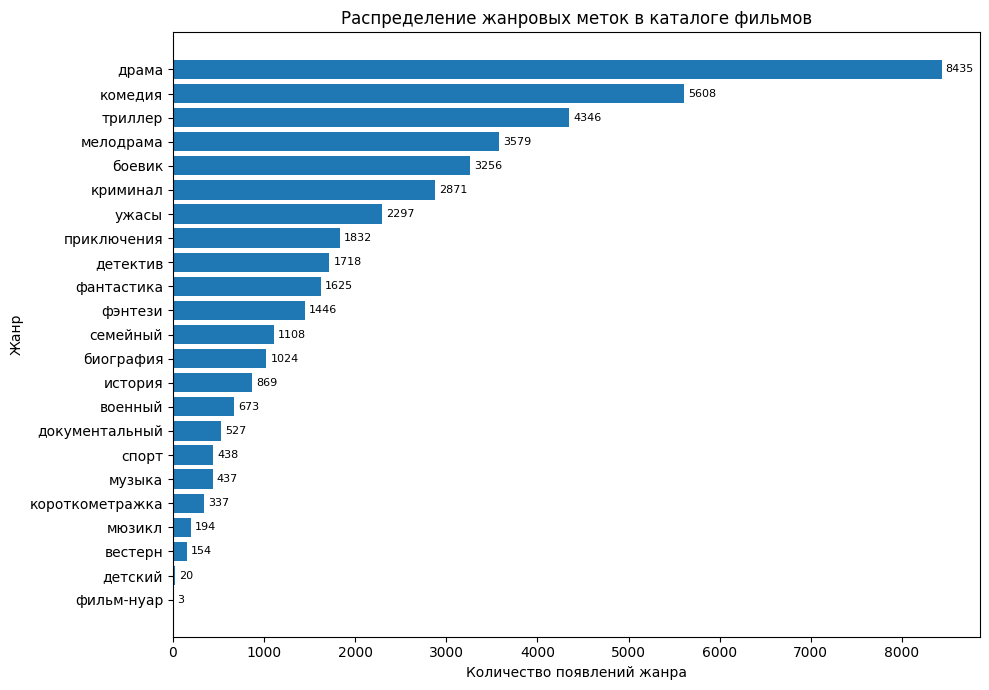

In [23]:
df_movies = df_copy.copy()

def parse_genres(x):
    if isinstance(x, list):
        return x
    if isinstance(x, str):
        try:
            return ast.literal_eval(x)
        except Exception:
            return []
    return []

# Если в df_copy жанры лежат в genres_list
if "genres_list" in df_movies.columns:
    df_movies["genres_list"] = df_movies["genres_list"].apply(parse_genres)

genre_counts = {}

for genres in df_movies["genres_list"]:
    for genre in genres:
        genre_counts[genre] = genre_counts.get(genre, 0) + 1

genre_df = (
    pd.DataFrame({
        "genre": list(genre_counts.keys()),
        "count": list(genre_counts.values())
    })
    .sort_values("count", ascending=True)
)

plt.figure(figsize=(10, 7))
bars = plt.barh(genre_df["genre"], genre_df["count"])

plt.title("Распределение жанровых меток в каталоге фильмов")
plt.xlabel("Количество появлений жанра")
plt.ylabel("Жанр")

plt.bar_label(bars, padding=3, fontsize=8)

plt.tight_layout()
plt.savefig("pictures/genre_distribution.png", dpi=300, bbox_inches="tight")
plt.show()